# Example Notebook for Harris & Speagle (2023): Photometric Completeness Modelled With Neural Networks

This notebook provides examples for how to use the neural networks trained and tested as part of Harris & Speagle (2023) to reproduce some of the results, test different aspects of the performance, and train similar neural networks on your own.

If you have questions about the contents included below, please contact Josh Speagle (j.speagle@utoronto.ca) and Bill Harris (harris@physics.mcmaster.ca).

In [1]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
import sklearn
from sklearn.neural_network import MLPClassifier

%matplotlib inline

## Loading in Data

The Zeonodo link includes the artificial star test (AST) data used to train each model. The format in which these are stored are slightly different and enumerated in the notebook below.

In [2]:
# NGC 1275 with a flat/steep LF
# 0: x position (pix)
# 1: y position (pix)
# 2: radius from cluster center (arcsec)
# 3: F475W_input (input mag)
# 4: F814W_input (input mag)
# 5: F475W_meas (measured mag)
# 6: F814W_meas (measured mag)
# 7: Sky noise (see paper)
# 8: Crowding (see paper)
# 9: Recovered? (1/0 = yes/no)
data_ngc1275_flat = np.loadtxt('ngc1275_flat_ast.dat')
data_ngc1275_steep = np.loadtxt('ngc1275_steep_ast.dat')

# NGC 3377
# 0: x position (pix)
# 1: y position (pix)
# 2: radius from cluster center (arcmin)
# 3: F606W_input (input mag)
# 4: F814W_input (input mag)
# 5: F606W_meas (measured mag)
# 6: F814W_meas (measured mag)
# 7: Combined background/crowding (see paper)
# 8: Recovered? (1/0 = yes/no)
data_ngc3377 = np.loadtxt('ngc3377_ast.dat')

Transforming these into the inputs expected for each of the NN models is done below. Note that the NNs are specifically trained on the *measured* quantities so that they implicitly account for potential biases/scattering as part of the detection and measurement process.

In [3]:
# NGC 1275 (flat LF)
n_ngc1275_flat = len(data_ngc1275_flat)  # number
mag_meas = data_ngc1275_flat[:, 5]  # F475W
color_meas = data_ngc1275_flat[:, 5] - data_ngc1275_flat[:, 6]  # F475W - F814W
skynoise, crowd = data_ngc1275_flat[:, 7:9].T  # sky noise and crowding
recovered = np.array(data_ngc1275_flat[:, 9], dtype='int')  # recovery class
X_ngc1275_flat = np.c_[mag_meas, color_meas, skynoise, crowd]  # NN inputs (all)
Y_ngc1275_flat = np.array(recovered)  # NN targets

# NGC 1275 (steep LF)
n_ngc1275_steep = len(data_ngc1275_steep)  # number
mag_meas = data_ngc1275_steep[:, 5]  # F475W
color_meas = data_ngc1275_steep[:, 5] - data_ngc1275_steep[:, 6]  # F475W - F814W
skynoise, crowd = data_ngc1275_steep[:, 7:9].T  # sky noise and crowding
recovered = np.array(data_ngc1275_steep[:, 9], dtype='int')  # recovery class
X_ngc1275_steep = np.c_[mag_meas, color_meas, skynoise, crowd]  # NN inputs (all)
Y_ngc1275_steep = np.array(recovered)  # NN targets

# NGC 3377
n_ngc3377 = len(data_ngc3377)
mag_meas = data_ngc3377[:, 6]  # F814W
color_meas = data_ngc3377[:, 5] - data_ngc3377[:, 6]  # F606W - F814W
bkgcrowd = np.exp(data_ngc3377[:, 7].T)  # bkgcrowd (note the exp!)
recovered = np.array(data_ngc3377[:, 8], dtype='int')  # recovery class
X_ngc3377 = np.c_[mag_meas, color_meas, bkgcrowd]  # NN inputs (all)
Y_ngc3377 = np.array(recovered)  # NN targets

In [4]:
np.shape(X_ngc1275_flat)

(260359, 4)

## Create my own dataset

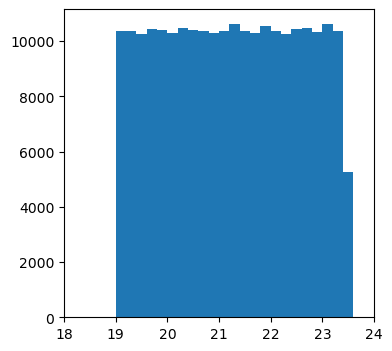

In [5]:
from astropy.table import Table

scratch_dir = "/pscratch/sd/v/virajvm"
complete_train = Table.read(scratch_dir + "/fsps_model_spec_summs_V2/summary_emi_total_v2.csv")
complete_train["MAG_R"] = complete_train["MAG_R"] - 2.5*np.log10( complete_train["flux_factor"])
complete_train["HALPHA_EW"] = np.abs(complete_train["HALPHA_EW"])

purity_train = complete_train[complete_train["ZRR_180s"] < 0.15]

plt.figure(figsize = (4,4))
plt.hist(complete_train["MAG_R"], bins = 30, range=(18,24))
plt.xlim([18,24])
plt.show()


In [6]:
def catas_redshift(z_true, z_meas,cut = 0.0033):
    '''
    The fidicual cut is for redshift to be consistent to within 1000 km/s. Function returns True if redshift is consistent
    '''
    
    temp_vals = np.abs(z_true - z_meas) / (1 + z_true)
    
    return (temp_vals < cut)

X_180s_pw = np.c_[purity_train["MAG_R"].data, purity_train["HALPHA_EW"].data, np.log10(purity_train["DELTACHI2_180s"].data)]  # NN inputs (all)
Y_180s_pw = catas_redshift(purity_train["Z"],purity_train["ZRR_180s"]).astype(int)  # NN targets


X_180s_cw = np.c_[complete_train["MAG_R"].data, complete_train["HALPHA_EW"].data, np.log10(complete_train["DELTACHI2_180s"].data)]  # NN inputs (all)
Y_180s_cw = catas_redshift(complete_train["Z"],complete_train["ZRR_180s"]).astype(int)  # NN targets

print(np.shape(X_180s_pw), np.shape(X_180s_cw))

(186688, 3) (234000, 3)


## Loading in Neural Network Models

The neural network (NN) models are trained using [scikit-learn's MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) and stored as `joblib` files. The naming structure follows the following convention: `nn_clf_[cluster name]_[optional descriptor]_[variable flags]_[optional training size]`. A few examples are listed below:
- `nn_clf_ngc1275_flat_1111_-1.5.joblib`: 
  - The `nn_clf` prefix indicates this is a NN classifier model. (All the models provided are NN classifier models.)
  - `ngc1275_flat` highlights that this model was trained on artificial star test (AST) data for NGC 1275, and that it used a "flat" luminosity function (as opposed to a "steep" luminosity function).
  - `1111` means that this model included all input parameters as part of the training, i.e. it included the F475W magnitude (1), F475W - F814W colour (1), the sky noise (1), and the crowding (1) parameters.
  - `-1.5` indicates that the training set (originally 80% of the input data) was reduced to $10^{-1.5} \approx 0.032$ of its original size.
- `nn_clf_ngc3377_110.joblib`:
  - As above, the `nn_clf` prefix indicates this is a NN classifier model.
  - `ngc3377` indicates the model was trained on AST data for NGC 3377 (there was only one luminosity function explored in the paper).
  - `110` means that the model included the first two parameters but not the third as part of the training, i.e. it included the F814W magnitude (1) and the F606W - F814W colour (1) but not the local crowding/background (0).
  
**For reference, the default, full-complexity, and fully-trained neural networks are:**
- **`nn_clf_ngc1275_flat_1111.joblib`**
- **`nn_clf_ngc1275_steep_1111.joblib`**
- **`nn_clf_ngc3377_111.joblib`**

Note that this example notebook assumes that, after downloading all files from the Zenodo link, you have organized the corresponding NN and AST files into a slightly more organized file structure. As a result, you might need to slightly modify the code below.

In [4]:
from joblib import dump, load


# load in default models

# ordered potential inputs to NGC 1275 models are: [F475W, F475W - F814W, skynoise, crowd]
clf_ngc1275_flat = load('NNs/ngc_1275_flat/nn_clf_ngc1275_flat_1111.joblib')
clf_ngc1275_steep = load('NNs/ngc_1275_steep/nn_clf_ngc1275_steep_1111.joblib')

# order potential inputs to NGC 337 model are: [F814W, F606W - F814W, bkgcrowd]
clf_ngc3377 = load('NNs/ngc_3377/nn_clf_ngc3377_111.joblib')

As always, we can get more info on these models using the `help()` function.

In [5]:
# See also:
# https://scikit-learn.org/stable/modules/neural_networks_supervised.html
help(clf_ngc3377)

Help on MLPClassifier in module sklearn.neural_network._multilayer_perceptron object:

class MLPClassifier(sklearn.base.ClassifierMixin, BaseMultilayerPerceptron)
 |  MLPClassifier(hidden_layer_sizes=(100,), activation='relu', *, solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=200, shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000)
 |  
 |  Multi-layer Perceptron classifier.
 |  
 |  This model optimizes the log-loss function using LBFGS or stochastic
 |  gradient descent.
 |  
 |  .. versionadded:: 0.18
 |  
 |  Parameters
 |  ----------
 |  hidden_layer_sizes : array-like of shape(n_layers - 2,), default=(100,)
 |      The ith element represents the number of neurons in the ith
 |      hidden layer.
 |  
 |  activation : {'i

## Using the Neural Network Models

The neural network models should generally be used to predict the recovery probability for an input object (i.e. how likely an object with the measured photometry would be recovered on average). Some examples are shown below.

In [6]:
# generating predictions for a multiple objects
# the output format is 2 columns: the first is P(Class=0), the second is P(Class=1)
# P(Class=1) is probability of recovery given the inputs

# predict probability
print('Input:', X_ngc1275_flat[5:10])
print('NN Output:', clf_ngc1275_flat.predict_proba(X_ngc1275_flat[5:10]))  # return both
print('P(recover):', clf_ngc1275_flat.predict_proba(X_ngc1275_flat[5:10])[:, 1])  # return just P(recover)

# predict log-probability
print('Input:', X_ngc1275_flat[5:10])
print('NN Output:', clf_ngc1275_flat.predict_log_proba(X_ngc1275_flat[5:10]))  # direct call
print('Math Check:', np.log(clf_ngc1275_flat.predict_proba(X_ngc1275_flat[5:10])))  # check

Input: [[27.665  2.279  3.244  6.802]
 [26.284  1.542  3.098  6.802]
 [25.459  0.847  3.418  6.397]
 [29.21   3.358  3.459  6.109]
 [27.93  -0.42   2.92   7.09 ]]
NN Output: [[0.21710557 0.78289443]
 [0.02224194 0.97775806]
 [0.01294968 0.98705032]
 [0.99517294 0.00482706]
 [0.10327993 0.89672007]]
P(recover): [0.78289443 0.97775806 0.98705032 0.00482706 0.89672007]
Input: [[27.665  2.279  3.244  6.802]
 [26.284  1.542  3.098  6.802]
 [25.459  0.847  3.418  6.397]
 [29.21   3.358  3.459  6.109]
 [27.93  -0.42   2.92   7.09 ]]
NN Output: [[-1.52737156e+00 -2.44757417e-01]
 [-3.80577570e+00 -2.24930193e-02]
 [-4.34668394e+00 -1.30342615e-02]
 [-4.83874410e-03 -5.33351847e+00]
 [-2.27031220e+00 -1.09011540e-01]]
Math Check: [[-1.52737156e+00 -2.44757417e-01]
 [-3.80577570e+00 -2.24930193e-02]
 [-4.34668394e+00 -1.30342615e-02]
 [-4.83874410e-03 -5.33351847e+00]
 [-2.27031220e+00 -1.09011540e-01]]


In addition to the probability, we can also get the predicted class directly (i.e. 1/0 = recovered/lost) under the assumption that $P({\rm recovered}) \geq 0.5$.

In [7]:
# we can also get the predicted class directly (if we want to use P > 0.5 as the cutoff)
print('Recovered?', clf_ngc1275_flat.predict(X_ngc1275_flat[5:10]))

Recovered? [1 1 1 0 1]


Finally, note that generating predictions for a single object requires promoting the data to a 2-D array.

In [8]:
# generating predictions for a single object requires
# promoting the data to a 2-D array
print('Input:', X_ngc3377[7])
print('Recovery Probability:', clf_ngc3377.predict_proba(np.atleast_2d(X_ngc3377[7]))[0, 1])

Input: [27.886       0.897       0.09995852]
Recovery Probability: 0.7960216893650431


## An Example Figure

We will now use the NN models to make an few example figure to highlight the properties of the AST data and the NN models.

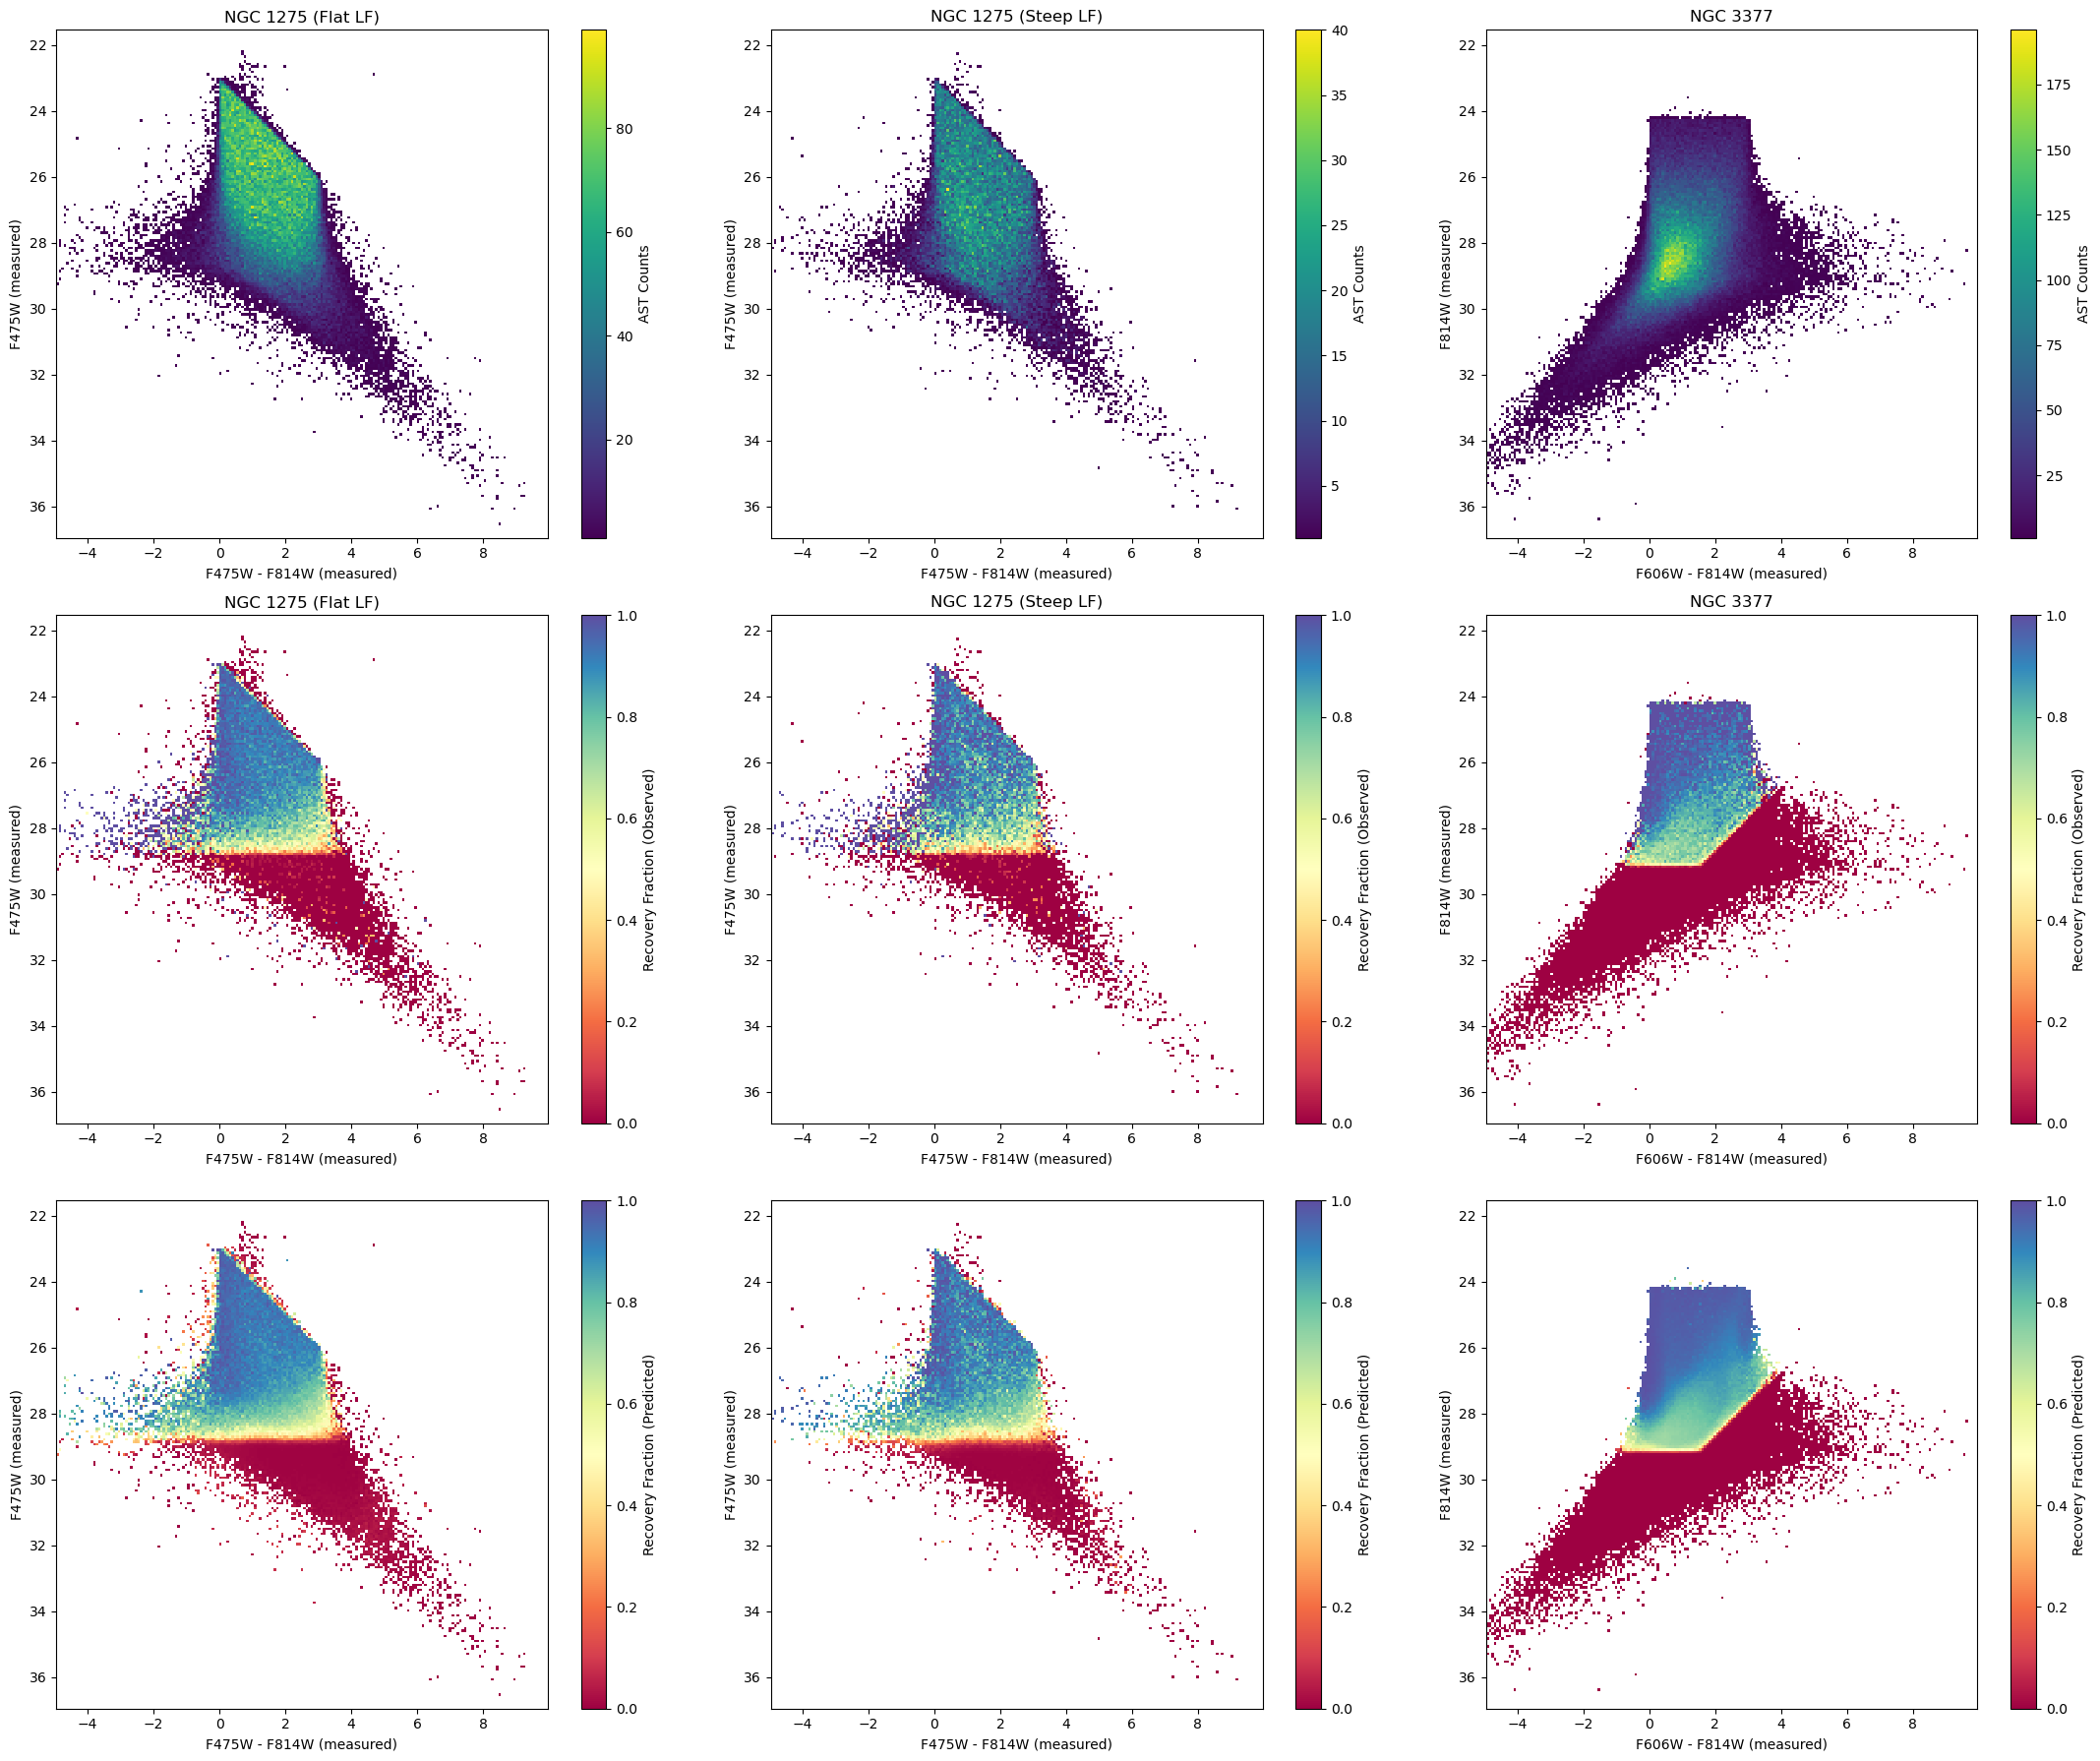

In [9]:
# plot CMD with coloring based on classification
xbins, ybins = np.linspace(-5, 10, 200), np.linspace(21.5, 37, 200)
xctrs, yctrs = 0.5 * (xbins[1:] + xbins[:-1]), 0.5 * (ybins[1:] + ybins[:-1])

plt.figure(figsize=(22, 18))

# counts
plt.subplot(3, 3, 1)
n1, _, _ = np.histogram2d(X_ngc1275_flat[:, 1], X_ngc1275_flat[:, 0], 
                          bins=[xbins, ybins])
n1[n1 == 0] = np.nan
plt.imshow(n1.T, origin='lower', interpolation='nearest',
           cmap='viridis', 
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
plt.xlabel('F475W - F814W (measured)')
plt.ylabel('F475W (measured)')
plt.ylim([yctrs[-1], yctrs[0]])
plt.xlim([xctrs[0], xctrs[-1]])
plt.colorbar(label='AST Counts')
plt.title('NGC 1275 (Flat LF)')

plt.subplot(3, 3, 2)
n1, _, _ = np.histogram2d(X_ngc1275_steep[:, 1], X_ngc1275_steep[:, 0], 
                          bins=[xbins, ybins])
n1[n1 == 0] = np.nan
plt.imshow(n1.T, origin='lower', interpolation='nearest',
           cmap='viridis',
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
plt.xlabel('F475W - F814W (measured)')
plt.ylabel('F475W (measured)')
plt.ylim([yctrs[-1], yctrs[0]])
plt.xlim([xctrs[0], xctrs[-1]])
plt.colorbar(label='AST Counts')
plt.title('NGC 1275 (Steep LF)')

plt.subplot(3, 3, 3)
n1, _, _ = np.histogram2d(X_ngc3377[:, 1], X_ngc3377[:, 0],
                          bins=[xbins, ybins])
n1[n1 == 0] = np.nan
plt.imshow(n1.T, origin='lower', interpolation='nearest',
           cmap='viridis',
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
plt.xlabel('F606W - F814W (measured)')
plt.ylabel('F814W (measured)')
plt.ylim([yctrs[-1], yctrs[0]])
plt.xlim([xctrs[0], xctrs[-1]])
plt.colorbar(label='AST Counts')
plt.title('NGC 3377')

# data
plt.subplot(3, 3, 4)
n1, _, _ = np.histogram2d(X_ngc1275_flat[:, 1], X_ngc1275_flat[:, 0], 
                          bins=[xbins, ybins])
h1, _, _ = np.histogram2d(X_ngc1275_flat[:, 1], X_ngc1275_flat[:, 0], 
                          bins=[xbins, ybins], 
                          weights=Y_ngc1275_flat)
n1[n1 == 0] = np.nan
plt.imshow((h1/n1).T, origin='lower', interpolation='nearest',
           cmap='Spectral', vmin=0, vmax=1,
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
plt.xlabel('F475W - F814W (measured)')
plt.ylabel('F475W (measured)')
plt.ylim([yctrs[-1], yctrs[0]])
plt.xlim([xctrs[0], xctrs[-1]])
plt.colorbar(label='Recovery Fraction (Observed)')
plt.title('NGC 1275 (Flat LF)')

plt.subplot(3, 3, 5)
n1, _, _ = np.histogram2d(X_ngc1275_steep[:, 1], X_ngc1275_steep[:, 0], 
                          bins=[xbins, ybins])
h1, _, _ = np.histogram2d(X_ngc1275_steep[:, 1], X_ngc1275_steep[:, 0], 
                          bins=[xbins, ybins], 
                          weights=Y_ngc1275_steep)
n1[n1 == 0] = np.nan
plt.imshow((h1/n1).T, origin='lower', interpolation='nearest',
           cmap='Spectral', vmin=0, vmax=1,
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
plt.xlabel('F475W - F814W (measured)')
plt.ylabel('F475W (measured)')
plt.ylim([yctrs[-1], yctrs[0]])
plt.xlim([xctrs[0], xctrs[-1]])
plt.colorbar(label='Recovery Fraction (Observed)')
plt.title('NGC 1275 (Steep LF)')

plt.subplot(3, 3, 6)
n1, _, _ = np.histogram2d(X_ngc3377[:, 1], X_ngc3377[:, 0],
                          bins=[xbins, ybins])
h1, _, _ = np.histogram2d(X_ngc3377[:, 1], X_ngc3377[:, 0],
                          bins=[xbins, ybins], 
                          weights=Y_ngc3377)
n1[n1 == 0] = np.nan
plt.imshow((h1/n1).T, origin='lower', interpolation='nearest',
           cmap='Spectral', vmin=0, vmax=1,
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
plt.xlabel('F606W - F814W (measured)')
plt.ylabel('F814W (measured)')
plt.ylim([yctrs[-1], yctrs[0]])
plt.xlim([xctrs[0], xctrs[-1]])
plt.colorbar(label='Recovery Fraction (Observed)')
plt.title('NGC 3377')

# model
plt.subplot(3, 3, 7)
n1, _, _ = np.histogram2d(X_ngc1275_flat[:, 1], X_ngc1275_flat[:, 0],
                          bins=[xbins, ybins])
h1, _, _ = np.histogram2d(X_ngc1275_flat[:, 1], X_ngc1275_flat[:, 0],
                          bins=[xbins, ybins], 
                          weights=clf_ngc1275_flat.predict_proba(X_ngc1275_flat)[:, 1])
n1[n1 == 0] = np.nan
plt.imshow((h1/n1).T, origin='lower', interpolation='nearest',
           cmap='Spectral', vmin=0, vmax=1,
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
plt.xlabel('F475W - F814W (measured)')
plt.ylabel('F475W (measured)')
plt.ylim([yctrs[-1], yctrs[0]])
plt.xlim([xctrs[0], xctrs[-1]])
plt.colorbar(label='Recovery Fraction (Predicted)')

plt.subplot(3, 3, 8)
n1, _, _ = np.histogram2d(X_ngc1275_steep[:, 1], X_ngc1275_steep[:, 0], 
                          bins=[xbins, ybins])
h1, _, _ = np.histogram2d(X_ngc1275_steep[:, 1], X_ngc1275_steep[:, 0], 
                          bins=[xbins, ybins], 
                          weights=clf_ngc1275_steep.predict_proba(X_ngc1275_steep)[:, 1])
n1[n1 == 0] = np.nan
plt.imshow((h1/n1).T, origin='lower', interpolation='nearest',
           cmap='Spectral', vmin=0, vmax=1,
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
plt.xlabel('F475W - F814W (measured)')
plt.ylabel('F475W (measured)')
plt.ylim([yctrs[-1], yctrs[0]])
plt.xlim([xctrs[0], xctrs[-1]])
plt.colorbar(label='Recovery Fraction (Predicted)')

plt.subplot(3, 3, 9)
n1, _, _ = np.histogram2d(X_ngc3377[:, 1], X_ngc3377[:, 0], bins=[xbins, ybins])
h1, _, _ = np.histogram2d(X_ngc3377[:, 1], X_ngc3377[:, 0], bins=[xbins, ybins], 
                          weights=clf_ngc3377.predict_proba(X_ngc3377)[:, 1])
n1[n1 == 0] = np.nan
plt.imshow((h1/n1).T, origin='lower', interpolation='nearest',
           cmap='Spectral', vmin=0, vmax=1,
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
plt.xlabel('F606W - F814W (measured)')
plt.ylabel('F814W (measured)')
plt.ylim([yctrs[-1], yctrs[0]])
plt.xlim([xctrs[0], xctrs[-1]])
plt.colorbar(label='Recovery Fraction (Predicted)')

plt.tight_layout()

## Training a New Neural Network Model

If you want to replicate our general training procedure, you can build off of the example code below.

In [11]:
np.random.seed(20230329)  # arbitrary random seed for reproducibility

# decleare inputs and targets
X, Y = X_ngc1275_flat, Y_ngc1275_flat
n = len(Y)

# split randomly into training and testing sets
idxs = np.random.choice(np.arange(n), size=n, replace=False)
idxs_train, idxs_test = idxs[:int(0.8 * n)], idxs[int(0.8 * n):]
X_train, Y_train = X[idxs_train], Y[idxs_train]
X_test, Y_test = X[idxs_test], Y[idxs_test]

# train NN classifier
learning_rates = np.logspace(-2.5, -4, 10)
clf = MLPClassifier(solver='adam', activation='relu', 
                    hidden_layer_sizes=(200, 200, 200), 
                    alpha=1e-4,
                    learning_rate='constant', learning_rate_init=1e-3,
                    batch_size=256, max_iter=50, n_iter_no_change=np.inf, 
                    warm_start=True, verbose=True)

# go through a learning rate schedule
print('Training/20:')
for i, lr in enumerate(learning_rates):
    clf.learning_rate_init = lr
    clf.fit(X_train[::20], Y_train[::20])
print('Training/10:')
for i, lr in enumerate(learning_rates[5:]):
    clf.learning_rate_init = lr
    clf.fit(X_train[::10], Y_train[::10])
print('Training/5:')
for i, lr in enumerate(learning_rates[5:]):
    clf.learning_rate_init = lr
    clf.fit(X_train[::5], Y_train[::5])
print('Training:')
for i, lr in enumerate(learning_rates[5:]):
    clf.learning_rate_init = lr
    clf.fit(X_train, Y_train)
print('Final Training:')
clf.learning_rate_init = lr
clf.max_iter = 100 
clf.fit(X_train, Y_train)

Training/20:
Iteration 1, loss = 0.67012197
Iteration 2, loss = 0.26604198
Iteration 3, loss = 0.25792745
Iteration 4, loss = 0.25621488
Iteration 5, loss = 0.25427786
Iteration 6, loss = 0.24852530
Iteration 7, loss = 0.23932950
Iteration 8, loss = 0.24173915
Iteration 9, loss = 0.22981913
Iteration 10, loss = 0.23684920
Iteration 11, loss = 0.22647762
Iteration 12, loss = 0.22478383
Iteration 13, loss = 0.23499775
Iteration 14, loss = 0.21777584
Iteration 15, loss = 0.22504330
Iteration 16, loss = 0.23007637
Iteration 17, loss = 0.21112808
Iteration 18, loss = 0.21054624
Iteration 19, loss = 0.21489312
Iteration 20, loss = 0.22474009
Iteration 21, loss = 0.21216579
Iteration 22, loss = 0.20689812
Iteration 23, loss = 0.21875738
Iteration 24, loss = 0.21138440
Iteration 25, loss = 0.21233560
Iteration 26, loss = 0.19872347
Iteration 27, loss = 0.20830002
Iteration 28, loss = 0.19699000
Iteration 29, loss = 0.20508181
Iteration 30, loss = 0.19448175
Iteration 31, loss = 0.19258067
Iter

/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.17492616
Iteration 3, loss = 0.17090540
Iteration 4, loss = 0.17088144
Iteration 5, loss = 0.18158819
Iteration 6, loss = 0.17289792
Iteration 7, loss = 0.16999369
Iteration 8, loss = 0.18477345
Iteration 9, loss = 0.17907855
Iteration 10, loss = 0.16648057
Iteration 11, loss = 0.16128488
Iteration 12, loss = 0.17490689
Iteration 13, loss = 0.16977899
Iteration 14, loss = 0.16100232
Iteration 15, loss = 0.16882809
Iteration 16, loss = 0.16721687
Iteration 17, loss = 0.15961786
Iteration 18, loss = 0.16799357
Iteration 19, loss = 0.15798992
Iteration 20, loss = 0.16142531
Iteration 21, loss = 0.15790109
Iteration 22, loss = 0.17719285
Iteration 23, loss = 0.17667355
Iteration 24, loss = 0.17850372
Iteration 25, loss = 0.16830092
Iteration 26, loss = 0.16944715
Iteration 27, loss = 0.15636325
Iteration 28, loss = 0.15783298
Iteration 29, loss = 0.15793924
Iteration 30, loss = 0.15617518
Iteration 31, loss = 0.15828008
Iteration 32, loss = 0.15345681
Iteration 33, lo

/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2, loss = 0.15199651
Iteration 3, loss = 0.14948971
Iteration 4, loss = 0.14942308
Iteration 5, loss = 0.15514140
Iteration 6, loss = 0.15570662
Iteration 7, loss = 0.14574269
Iteration 8, loss = 0.15938163
Iteration 9, loss = 0.15120577
Iteration 10, loss = 0.14796725
Iteration 11, loss = 0.14856658
Iteration 12, loss = 0.14610898
Iteration 13, loss = 0.15338412
Iteration 14, loss = 0.14730307
Iteration 15, loss = 0.14787752
Iteration 16, loss = 0.15392468
Iteration 17, loss = 0.15378822
Iteration 18, loss = 0.16006052
Iteration 19, loss = 0.15176283
Iteration 20, loss = 0.14546898
Iteration 21, loss = 0.15134453
Iteration 22, loss = 0.15186060
Iteration 23, loss = 0.14889236
Iteration 24, loss = 0.15494251
Iteration 25, loss = 0.14576297
Iteration 26, loss = 0.14487329
Iteration 27, loss = 0.17005049
Iteration 28, loss = 0.15474027
Iteration 29, loss = 0.15618071
Iteration 30, loss = 0.14989450
Iteration 31, loss = 0.14662097
Iteration 32, loss = 0.14805715
Iteration 33, lo

...

Iteration 1, loss = 0.13675945
Iteration 2, loss = 0.13713499
Iteration 3, loss = 0.13655104
Iteration 4, loss = 0.13659221
Iteration 5, loss = 0.13661386
Iteration 6, loss = 0.13690592
Iteration 7, loss = 0.13665583
Iteration 8, loss = 0.13641546
Iteration 9, loss = 0.13661035
Iteration 10, loss = 0.13665124
Iteration 11, loss = 0.13644095
Iteration 12, loss = 0.13657595
Iteration 13, loss = 0.13650806
Iteration 14, loss = 0.13685003
Iteration 15, loss = 0.13659770
Iteration 16, loss = 0.13654040
Iteration 17, loss = 0.13641975
Iteration 18, loss = 0.13659968
Iteration 19, loss = 0.13676067
Iteration 20, loss = 0.13645406
Iteration 21, loss = 0.13664894
Iteration 22, loss = 0.13644947
Iteration 23, loss = 0.13648793
Iteration 24, loss = 0.13699575
Iteration 25, loss = 0.13664859
Iteration 26, loss = 0.13663343
Iteration 27, loss = 0.13671157
Iteration 28, loss = 0.13662926
Iteration 29, loss = 0.13645498
Iteration 30, loss = 0.13656906
Iteration 31, loss = 0.13700435
Iteration 32, los

/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.13658030
Iteration 2, loss = 0.13638239
Iteration 3, loss = 0.13645027
Iteration 4, loss = 0.13677452
Iteration 5, loss = 0.13658290
Iteration 6, loss = 0.13628953
Iteration 7, loss = 0.13652758
Iteration 8, loss = 0.13646363
Iteration 9, loss = 0.13679887
Iteration 10, loss = 0.13664538
Iteration 11, loss = 0.13636976
Iteration 12, loss = 0.13643602
Iteration 13, loss = 0.13633670
Iteration 14, loss = 0.13628981
Iteration 15, loss = 0.13659838
Iteration 16, loss = 0.13662442
Iteration 17, loss = 0.13656866
Iteration 18, loss = 0.13647288
Iteration 19, loss = 0.13652392
Iteration 20, loss = 0.13633245
Iteration 21, loss = 0.13632098
Iteration 22, loss = 0.13632553
Iteration 23, loss = 0.13632391
Iteration 24, loss = 0.13670084
Iteration 25, loss = 0.13654477
Iteration 26, loss = 0.13633123
Iteration 27, loss = 0.13658883
Iteration 28, loss = 0.13655611
Iteration 29, loss = 0.13643374
Iteration 30, loss = 0.13630622
Iteration 31, loss = 0.13661579
Iteration 32, los

/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(batch_size=256, hidden_layer_sizes=(200, 200, 200),
              learning_rate_init=0.0001, max_iter=100, n_iter_no_change=inf,
              verbose=True, warm_start=True)

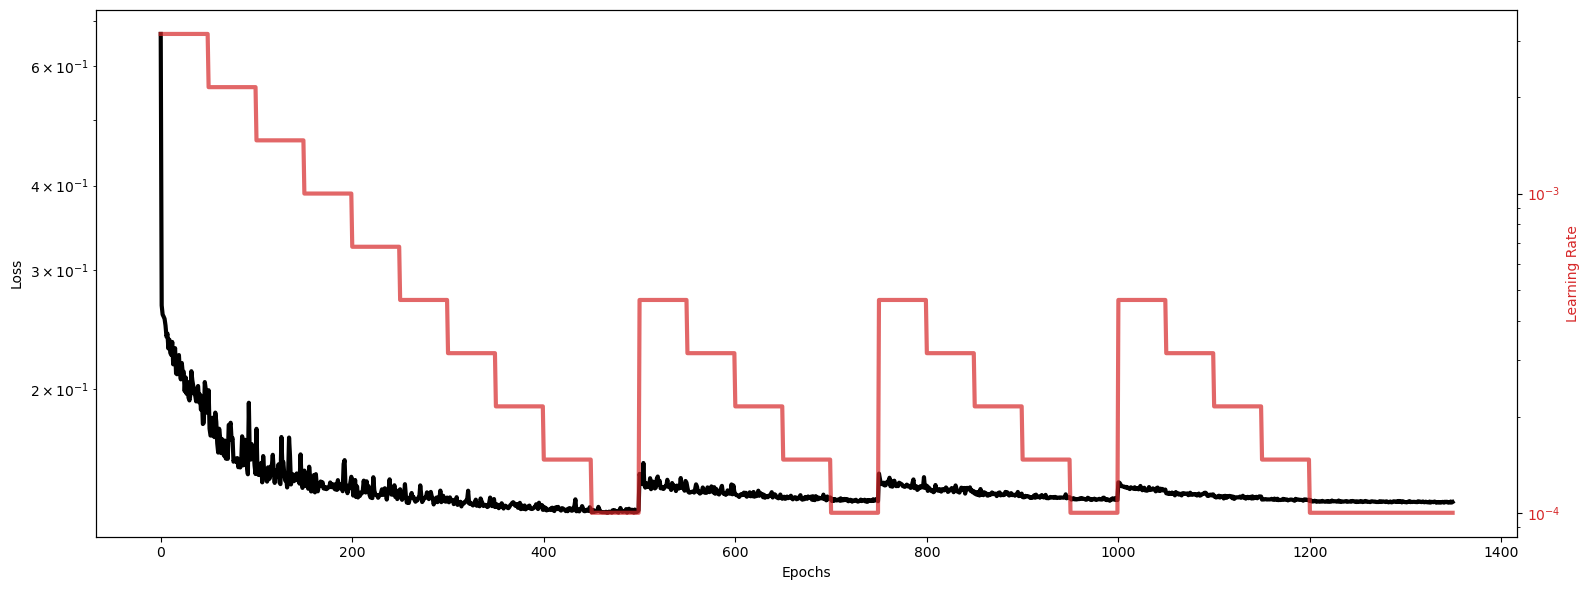

In [12]:
# plot learning rates and losses as a function of time
fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.semilogy(clf.loss_curve_, lw=3, color='black')
ax1.tick_params(axis='y')
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Learning Rate', color=color)
lr_grid = np.concatenate((np.repeat(learning_rates, 50),
                          np.repeat(learning_rates[5:], 50),
                          np.repeat(learning_rates[5:], 50),
                          np.repeat(learning_rates[5:], 50),
                          np.repeat(learning_rates[-1], 100)))
ax2.semilogy(lr_grid, lw=3, color=color, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()

In [13]:
help(clf)

Help on MLPClassifier in module sklearn.neural_network._multilayer_perceptron object:

class MLPClassifier(sklearn.base.ClassifierMixin, BaseMultilayerPerceptron)
 |  MLPClassifier(hidden_layer_sizes=(100,), activation='relu', *, solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=200, shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000)
 |  
 |  Multi-layer Perceptron classifier.
 |  
 |  This model optimizes the log-loss function using LBFGS or stochastic
 |  gradient descent.
 |  
 |  .. versionadded:: 0.18
 |  
 |  Parameters
 |  ----------
 |  hidden_layer_sizes : array-like of shape(n_layers - 2,), default=(100,)
 |      The ith element represents the number of neurons in the ith
 |      hidden layer.
 |  
 |  activation : {'i

In [14]:
# predict probability
print('Input:', X_ngc1275_flat[5:10])
print('NN Output:', clf.predict_proba(X_ngc1275_flat[5:10]))  # return both
print('P(recover):', clf.predict_proba(X_ngc1275_flat[5:10])[:, 1])  # return just P(recover)

# predict log-probability
print('Input:', X_ngc1275_flat[5:10])
print('NN Output:', clf.predict_log_proba(X_ngc1275_flat[5:10]))  # direct call
print('Math Check:', np.log(clf.predict_proba(X_ngc1275_flat[5:10])))  # check

Input: [[27.665  2.279  3.244  6.802]
 [26.284  1.542  3.098  6.802]
 [25.459  0.847  3.418  6.397]
 [29.21   3.358  3.459  6.109]
 [27.93  -0.42   2.92   7.09 ]]
NN Output: [[0.20099586 0.79900414]
 [0.01329568 0.98670432]
 [0.00976594 0.99023406]
 [0.99237151 0.00762849]
 [0.11042429 0.88957571]]
P(recover): [0.79900414 0.98670432 0.99023406 0.00762849 0.88957571]
Input: [[27.665  2.279  3.244  6.802]
 [26.284  1.542  3.098  6.802]
 [25.459  0.847  3.418  6.397]
 [29.21   3.358  3.459  6.109]
 [27.93  -0.42   2.92   7.09 ]]
NN Output: [[-1.60447098 -0.22438915]
 [-4.32031576 -0.01338486]
 [-4.62885473 -0.00981394]
 [-0.00765774 -4.87586486]
 [-2.20342516 -0.11701066]]
Math Check: [[-1.60447098 -0.22438915]
 [-4.32031576 -0.01338486]
 [-4.62885473 -0.00981394]
 [-0.00765774 -4.87586486]
 [-2.20342516 -0.11701066]]


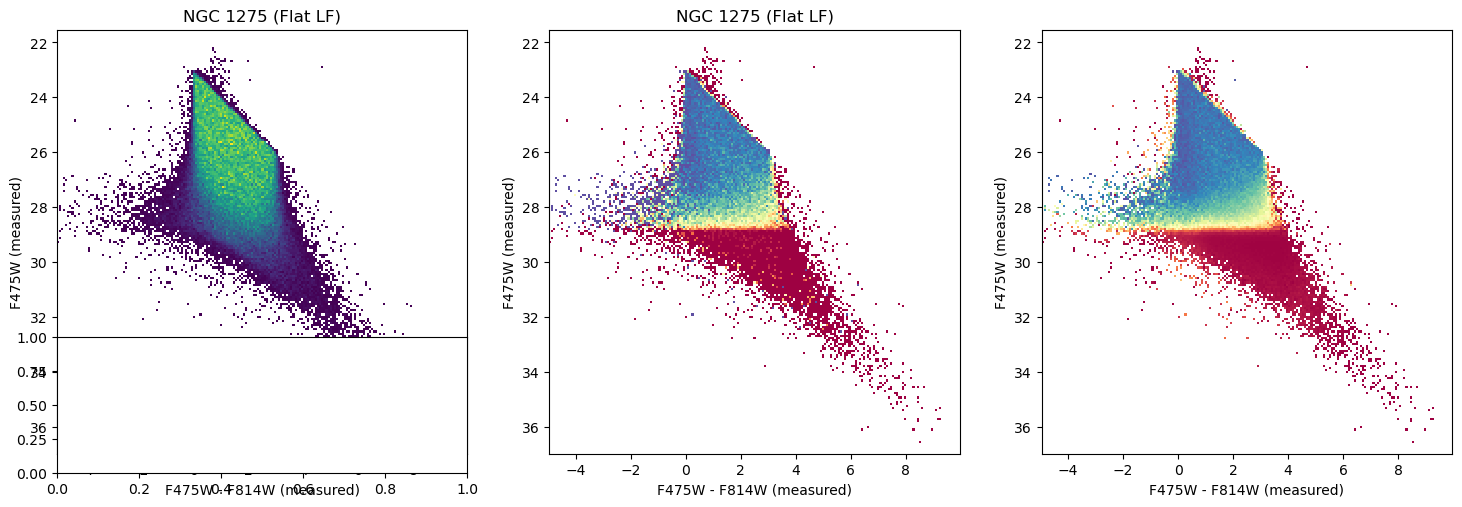

In [18]:
## make a prediction plot for the flat case 
# plot CMD with coloring based on classification
xbins, ybins = np.linspace(-5, 10, 200), np.linspace(21.5, 37, 200)
xctrs, yctrs = 0.5 * (xbins[1:] + xbins[:-1]), 0.5 * (ybins[1:] + ybins[:-1])

fig,ax = plt.subplots(1,3,figsize=(18, 6))

# counts
n1, _, _ = np.histogram2d(X_ngc1275_flat[:, 1], X_ngc1275_flat[:, 0], 
                          bins=[xbins, ybins])
n1[n1 == 0] = np.nan
ax[0].imshow(n1.T, origin='lower', interpolation='nearest',
           cmap='viridis', 
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
ax[0].set_xlabel('F475W - F814W (measured)')
ax[0].set_ylabel('F475W (measured)')
ax[0].set_ylim([yctrs[-1], yctrs[0]])
ax[0].set_xlim([xctrs[0], xctrs[-1]])
# ax[0].colorbar(label='AST Counts')
ax[0].set_title('NGC 1275 (Flat LF)')

# data
n1, _, _ = np.histogram2d(X_ngc1275_flat[:, 1], X_ngc1275_flat[:, 0], 
                          bins=[xbins, ybins])
h1, _, _ = np.histogram2d(X_ngc1275_flat[:, 1], X_ngc1275_flat[:, 0], 
                          bins=[xbins, ybins], 
                          weights=Y_ngc1275_flat)
n1[n1 == 0] = np.nan
ax[1].imshow((h1/n1).T, origin='lower', interpolation='nearest',
           cmap='Spectral', vmin=0, vmax=1,
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
ax[1].set_xlabel('F475W - F814W (measured)')
ax[1].set_ylabel('F475W (measured)')
ax[1].set_ylim([yctrs[-1], yctrs[0]])
ax[1].set_xlim([xctrs[0], xctrs[-1]])
# ax[1].colorbar(label='Recovery Fraction (Observed)')
ax[1].set_title('NGC 1275 (Flat LF)')



# model
plt.subplot(3, 3, 7)
n1, _, _ = np.histogram2d(X_ngc1275_flat[:, 1], X_ngc1275_flat[:, 0],
                          bins=[xbins, ybins])
h1, _, _ = np.histogram2d(X_ngc1275_flat[:, 1], X_ngc1275_flat[:, 0],
                          bins=[xbins, ybins], 
                          weights=clf.predict_proba(X_ngc1275_flat)[:, 1])
n1[n1 == 0] = np.nan
ax[2].imshow((h1/n1).T, origin='lower', interpolation='nearest',
           cmap='Spectral', vmin=0, vmax=1,
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]])
ax[2].set_xlabel('F475W - F814W (measured)')
ax[2].set_ylabel('F475W (measured)')
ax[2].set_ylim([yctrs[-1], yctrs[0]])
ax[2].set_xlim([xctrs[0], xctrs[-1]])
# ax[2].colorbar(label='Recovery Fraction (Predicted)')
# /plt.tight_layout()

plt.show()


#### Training my new model

In [7]:
np.random.seed(20230329)  # arbitrary random seed for reproducibility

# decleare inputs and targets
X, Y = X_180s_pw , Y_180s_pw 
n = len(Y)

# split randomly into training and testing sets
idxs = np.random.choice(np.arange(n), size=n, replace=False)
idxs_train, idxs_test = idxs[:int(0.8 * n)], idxs[int(0.8 * n):]
X_train, Y_train = X[idxs_train], Y[idxs_train]
X_test, Y_test = X[idxs_test], Y[idxs_test]

# train NN classifier
learning_rates = np.logspace(-2.5, -4, 10)
clf = MLPClassifier(solver='adam', activation='relu', 
                    hidden_layer_sizes=(200, 200, 200), 
                    alpha=1e-4,
                    learning_rate='constant', learning_rate_init=1e-3,
                    batch_size=256, max_iter=50, n_iter_no_change=np.inf, 
                    warm_start=True, verbose=True)

# go through a learning rate schedule
print('Training/20:')
for i, lr in enumerate(learning_rates):
    clf.learning_rate_init = lr
    clf.fit(X_train[::20], Y_train[::20])
print('Training/10:')
for i, lr in enumerate(learning_rates[5:]):
    clf.learning_rate_init = lr
    clf.fit(X_train[::10], Y_train[::10])
print('Training/5:')
for i, lr in enumerate(learning_rates[5:]):
    clf.learning_rate_init = lr
    clf.fit(X_train[::5], Y_train[::5])
print('Training:')
for i, lr in enumerate(learning_rates[5:]):
    clf.learning_rate_init = lr
    clf.fit(X_train, Y_train)
print('Final Training:')
clf.learning_rate_init = lr
clf.max_iter = 100 
clf.fit(X_train, Y_train)

Training/20:
Iteration 1, loss = 0.30393725
Iteration 2, loss = 0.12551320
Iteration 3, loss = 0.09079871
Iteration 4, loss = 0.08177151
Iteration 5, loss = 0.07747073
Iteration 6, loss = 0.08252964
Iteration 7, loss = 0.07168890
Iteration 8, loss = 0.06911442
Iteration 9, loss = 0.06914495
Iteration 10, loss = 0.07304166
Iteration 11, loss = 0.07243411
Iteration 12, loss = 0.06854470
Iteration 13, loss = 0.06913236
Iteration 14, loss = 0.07102789
Iteration 15, loss = 0.06987151
Iteration 16, loss = 0.07160897
Iteration 17, loss = 0.07137653
Iteration 18, loss = 0.07068663
Iteration 19, loss = 0.06870864
Iteration 20, loss = 0.06982846
Iteration 21, loss = 0.06785521
Iteration 22, loss = 0.06898555
Iteration 23, loss = 0.06885434
Iteration 24, loss = 0.06703115
Iteration 25, loss = 0.06663503
Iteration 26, loss = 0.06653471
Iteration 27, loss = 0.06834682
Iteration 28, loss = 0.06795385
Iteration 29, loss = 0.06677263
Iteration 30, loss = 0.06822488
Iteration 31, loss = 0.06965747
Iter

/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.07036240
Iteration 2, loss = 0.06752888
Iteration 3, loss = 0.06588885
Iteration 4, loss = 0.06574788
Iteration 5, loss = 0.06821576
Iteration 6, loss = 0.06843814
Iteration 7, loss = 0.06755210
Iteration 8, loss = 0.06557979
Iteration 9, loss = 0.06663533
Iteration 10, loss = 0.06649515
Iteration 11, loss = 0.06589547
Iteration 12, loss = 0.06635634
Iteration 13, loss = 0.06684107
Iteration 14, loss = 0.06556123
Iteration 15, loss = 0.06574916
Iteration 16, loss = 0.06589453
Iteration 17, loss = 0.07031352
Iteration 18, loss = 0.06573448
Iteration 19, loss = 0.06597940
Iteration 20, loss = 0.06534309
Iteration 21, loss = 0.06552761
Iteration 22, loss = 0.06645381
Iteration 23, loss = 0.06694256
Iteration 24, loss = 0.06728301
Iteration 25, loss = 0.06641481
Iteration 26, loss = 0.06533470
Iteration 27, loss = 0.06673777
Iteration 28, loss = 0.06468857
Iteration 29, loss = 0.06517080
Iteration 30, loss = 0.06518164
Iteration 31, loss = 0.06501053
Iteration 32, los

/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.07039756
Iteration 2, loss = 0.06477929
Iteration 3, loss = 0.06499151
Iteration 4, loss = 0.06505526
Iteration 5, loss = 0.06458933
Iteration 6, loss = 0.06351242
Iteration 7, loss = 0.06361906
Iteration 8, loss = 0.06448564
Iteration 9, loss = 0.06458970
Iteration 10, loss = 0.06413370
Iteration 11, loss = 0.06434446
Iteration 12, loss = 0.06392011
Iteration 13, loss = 0.06727286
Iteration 14, loss = 0.06399333
Iteration 15, loss = 0.06385923
Iteration 16, loss = 0.06349787
Iteration 17, loss = 0.06476294
Iteration 18, loss = 0.06440799
Iteration 19, loss = 0.06338621
Iteration 20, loss = 0.06365404
Iteration 21, loss = 0.06429166
Iteration 22, loss = 0.06357533
Iteration 23, loss = 0.06506412
Iteration 24, loss = 0.06389479
Iteration 25, loss = 0.06399151
Iteration 26, loss = 0.06395093
Iteration 27, loss = 0.06407040
Iteration 28, loss = 0.06365069
Iteration 29, loss = 0.06380938
Iteration 30, loss = 0.06432648
Iteration 31, loss = 0.06384065
Iteration 32, los

...

Iteration 1, loss = 0.06020848
Iteration 2, loss = 0.06019389
Iteration 3, loss = 0.06007821
Iteration 4, loss = 0.06001050
Iteration 5, loss = 0.06007903
Iteration 6, loss = 0.06012569
Iteration 7, loss = 0.05998697
Iteration 8, loss = 0.06004096
Iteration 9, loss = 0.06011029
Iteration 10, loss = 0.06035023
Iteration 11, loss = 0.06004416
Iteration 12, loss = 0.06003439
Iteration 13, loss = 0.06015281
Iteration 14, loss = 0.06003266
Iteration 15, loss = 0.06013036
Iteration 16, loss = 0.06014393
Iteration 17, loss = 0.06003706
Iteration 18, loss = 0.06010612
Iteration 19, loss = 0.05999466
Iteration 20, loss = 0.06000441
Iteration 21, loss = 0.06003300
Iteration 22, loss = 0.06010275
Iteration 23, loss = 0.05997201
Iteration 24, loss = 0.06004528
Iteration 25, loss = 0.05999382
Iteration 26, loss = 0.06011068
Iteration 27, loss = 0.06009296
Iteration 28, loss = 0.06007229
Iteration 29, loss = 0.06013165
Iteration 30, loss = 0.05997888
Iteration 31, loss = 0.06004073
Iteration 32, los

/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.05998789
Iteration 2, loss = 0.05995746
Iteration 3, loss = 0.05994466
Iteration 4, loss = 0.06005037
Iteration 5, loss = 0.05993947
Iteration 6, loss = 0.06000898
Iteration 7, loss = 0.06000008
Iteration 8, loss = 0.06009379
Iteration 9, loss = 0.06001920
Iteration 10, loss = 0.05996407
Iteration 11, loss = 0.05999408
Iteration 12, loss = 0.06003140
Iteration 13, loss = 0.06001123
Iteration 14, loss = 0.05996640
Iteration 15, loss = 0.06020638
Iteration 16, loss = 0.06008205
Iteration 17, loss = 0.05985807
Iteration 18, loss = 0.05983363
Iteration 19, loss = 0.05998173
Iteration 20, loss = 0.05997388
Iteration 21, loss = 0.05988065
Iteration 22, loss = 0.05999617
Iteration 23, loss = 0.05989790
Iteration 24, loss = 0.05989689
Iteration 25, loss = 0.05993100
Iteration 26, loss = 0.05994371
Iteration 27, loss = 0.06002519
Iteration 28, loss = 0.05998275
Iteration 29, loss = 0.05990806
Iteration 30, loss = 0.05988876
Iteration 31, loss = 0.05990356
Iteration 32, los

/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(batch_size=256, hidden_layer_sizes=(200, 200, 200),
              learning_rate_init=0.0001, max_iter=100, n_iter_no_change=inf,
              verbose=True, warm_start=True)

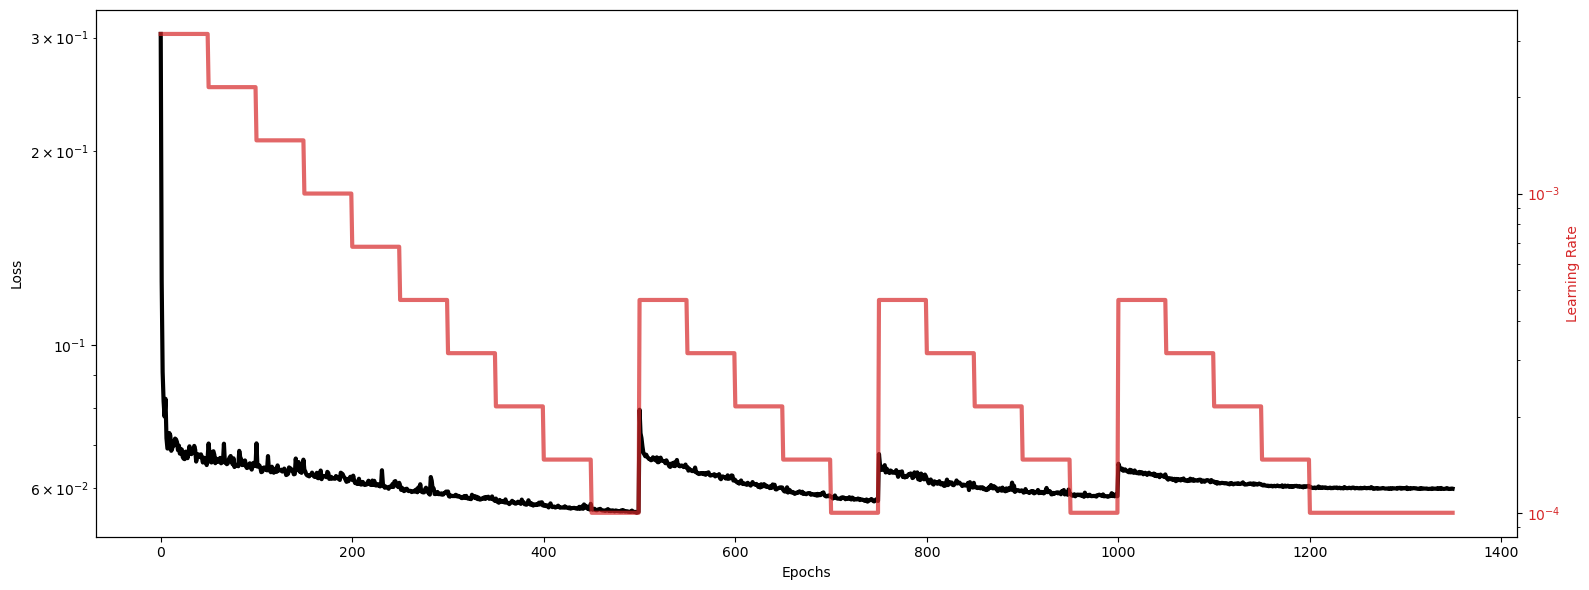

In [8]:
# plot learning rates and losses as a function of time
fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.semilogy(clf.loss_curve_, lw=3, color='black')
ax1.tick_params(axis='y')
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Learning Rate', color=color)
lr_grid = np.concatenate((np.repeat(learning_rates, 50),
                          np.repeat(learning_rates[5:], 50),
                          np.repeat(learning_rates[5:], 50),
                          np.repeat(learning_rates[5:], 50),
                          np.repeat(learning_rates[-1], 100)))
ax2.semilogy(lr_grid, lw=3, color=color, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()

In [8]:
# Save the trained model
from joblib import dump, load
# dump(clf, 'mlp_180s_pw.joblib')
# print("Model saved as 'mlp_model.joblib'.")

In [9]:
clf = load("mlp_180s_pw.joblib")

In [10]:
# predict probability
print('Input:', X_180s_pw[5:10])
print('NN Output:', clf.predict_proba(X_180s_pw[5:10]))  # return both
print('P(recover):', clf.predict_proba(X_180s_pw[5:10])[:, 1])  # return just P(recover)
print('P(true):', Y_180s_pw[5:10])

# predict log-probability
# print('Input:', X_180s_pw[5:10])
# print('NN Output:', clf.predict_log_proba(X_ngc1275_flat[5:10]))  # direct call
# print('Math Check:', np.log(clf.predict_proba(X_ngc1275_flat[5:10])))  # check

Input: [[22.85480394 50.49606737  1.48206101]
 [20.57205867 50.49606737  2.19435208]
 [20.16180033 50.49606737  2.35517261]
 [20.32708923 50.49606737  2.498142  ]
 [21.59457895 50.49606737  1.86218354]]
NN Output: [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]
P(recover): [1. 1. 1. 1. 1.]
P(true): [1 1 1 1 1]


In [12]:
## how would I evalute this??
np.array([[23,7.5,1],[23,7.5,1]  ])

array([[23. ,  7.5,  1. ],
       [23. ,  7.5,  1. ]])

In [44]:
import matplotlib as mpl
from matplotlib.colors import LogNorm

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False


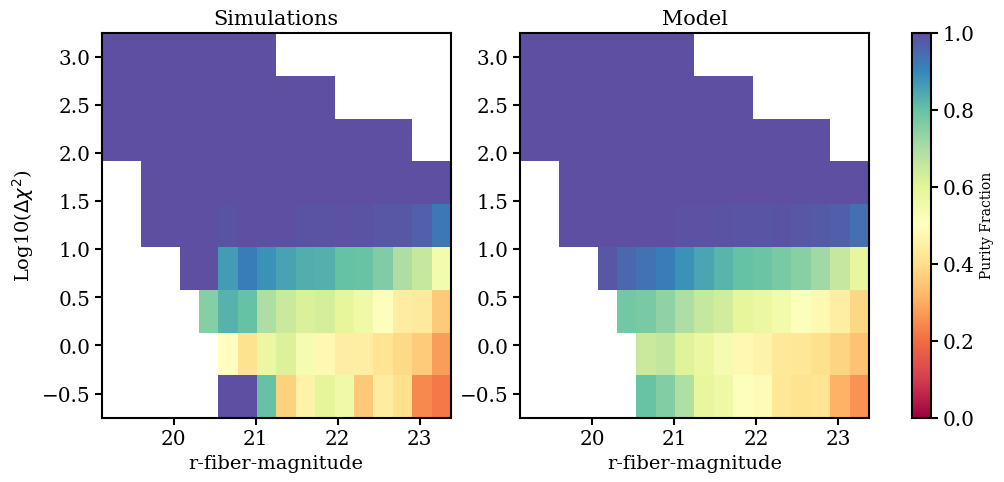

In [72]:
## make a prediction plot for the flat case 
# plot CMD with coloring based on classification
xbins, ybins = np.arange(19,23.75,0.25), np.arange(-1, 4, 0.5 )

xctrs, yctrs = 0.5 * (xbins[1:] + xbins[:-1]), 0.5 * (ybins[1:] + ybins[:-1])

var1 = 0
var2 = -1

fig,ax = plt.subplots(1,2,figsize=(11, 5))

# # counts
# n1, _, _ = np.histogram2d(X_180s_pw[:, var1], X_180s_pw[:, var2], 
#                           bins=[xbins, ybins])
# n1[n1 == 0] = np.nan

# ax[0].imshow(n1.T, origin='lower', interpolation='nearest',
#            cmap='viridis', 
#            extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]], aspect="auto")

# ax[0].set_xlabel('fiber mag')
# ax[0].set_ylabel('Dchi2')
# ax[0].set_ylim([yctrs[0], yctrs[-1]])
# ax[0].set_xlim([xctrs[0], xctrs[-1]])
# # ax[0].colorbar(label='AST Counts')

# # data
n1, _, _ = np.histogram2d(X_180s_pw[:, var1], X_180s_pw[:, var2], 
                          bins=[xbins, ybins])
h1, _, _ = np.histogram2d(X_180s_pw[:, var1], X_180s_pw[:, var2], 
                          bins=[xbins, ybins], 
                          weights=Y_180s_pw)
n1[n1 == 0] = np.nan

ax[0].set_title("Simulations",fontsize = 15)
im = ax[0].imshow((h1/n1).T, origin='lower', interpolation='nearest',
           cmap='Spectral', vmin=0, vmax=1,
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]], aspect="auto")
ax[0].set_xlabel('r-fiber-magnitude',fontsize = 14)
ax[0].set_ylabel(r'Log10($\Delta\chi^2$)',fontsize = 14)
# ax[0].set_ylabel(r'HALPHA EW',fontsize = 14)
ax[0].set_ylim([yctrs[0], yctrs[-1]])
ax[0].set_xlim([xctrs[0], xctrs[-1]])
fig.colorbar(im,ax=ax, location='right', label='Purity Fraction',fraction=0.05, pad=0.05 )



# # model
ax[1].set_title("Model",fontsize = 15)
n1, _, _ = np.histogram2d(X_180s_pw[:, var1], X_180s_pw[:, var2],
                          bins=[xbins, ybins])
h1, _, _ = np.histogram2d(X_180s_pw[:, var1], X_180s_pw[:, var2],
                          bins=[xbins, ybins], 
                          weights=clf.predict_proba(X_180s_pw)[:, 1])
n1[n1 == 0] = np.nan
ax[1].imshow((h1/n1).T, origin='lower', interpolation='nearest',
           cmap='Spectral', vmin=0, vmax=1,
           extent=[xctrs[0], xctrs[-1], yctrs[0], yctrs[-1]], aspect="auto")
ax[1].set_xlabel('r-fiber-magnitude',fontsize = 14)
# ax[1].set_ylabel(r'Log10($\Delta\chi^2$)',fontsize = 14)
ax[1].set_ylim([yctrs[0], yctrs[-1]])
ax[1].set_xlim([xctrs[0], xctrs[-1]])
# ax[2].colorbar(label='Recovery Fraction (Predicted)')
# /plt.tight_layout()

plt.show()


In [67]:
# clf.predict_proba(np.array([[23,5,np.log10(40)],[23,5,np.log10(40)]  ]))

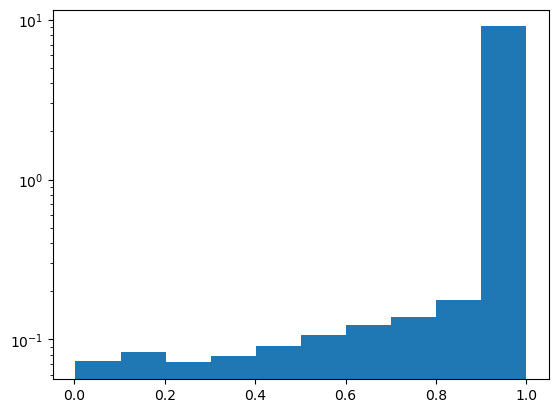

In [58]:
plt.hist(clf.predict_proba(X_180s_pw)[:, 1],density=True)
plt.yscale("log")
plt.show()

In [80]:

def plt_between(ax, xvals, med, err,color="k",alpha=0.2,plot_med=True,label = None,ls = "-"):
    ax.plot(xvals, med,color = color,label = label,ls = ls)
    ax.fill_between(xvals, med - err,med + err,alpha = alpha, color =color )
    return


def catas_redshift(z_true, z_meas,cut = 0.0033):
    '''
    The fidicual cut is for redshift to be consistent to within 1000 km/s. Function returns True if redshift is consistent
    '''
    
    temp_vals = np.abs(z_true - z_meas) / (1 + z_true)
    
    return (temp_vals < cut)



def get_purity_fracs(sum_tab, dchi2_bins, dchi2_lab=None, zwarn_lab = None, zrr_lab = None,return_catas_frac=False,min_count=5):
    '''
    
    Interestingly, it seems that even if one gets non 0/4 ZWARN flags, in the forward model spectra I do not get those?? Not sure why ... 
    Is there a reason for this? This could be hinting at some problem??
    '''
    purity_frac_900 = []
    purity_frac_900_err = []
    
    for i in range(len(dchi2_bins)-1):
        #filter for the relevant objects

        temp_sum = sum_tab[ (sum_tab[dchi2_lab] > dchi2_bins[i]) & (sum_tab[dchi2_lab] < dchi2_bins[i+1])]

        #then we need to get all the objects that have ZWARN = 0 or ZWARN = 4
        
        temp_sum = temp_sum[(temp_sum[zwarn_lab] == 0) | (temp_sum[zwarn_lab] == 4)]
        
        #then we find the redshifs with catastrophic failures
        # if return_catas_frac == False:
        isgood_zred = catas_redshift(temp_sum["Z"], temp_sum[zrr_lab])
        # if return_catas_frac:
        #     isgood_zred = ~catas_redshift(temp_sum["Z"], temp_sum[zrr_lab])
        
        #this is the min_count
        if len(temp_sum) > min_count:
            #then compute the purity fraction
            pure_frac = np.sum(isgood_zred)/len(isgood_zred)

            purity_frac_900.append(pure_frac)
            purity_frac_900_err.append(  np.sqrt( pure_frac * (1-pure_frac) / len(isgood_zred) ) )
        else:
            purity_frac_900.append(np.nan)
            purity_frac_900_err.append( np.nan )

        
    return purity_frac_900, purity_frac_900_err


In [138]:

from mpl_toolkits.axes_grid1 import Divider, Size
import matplotlib
import matplotlib.pyplot as plt

def make_subplots(ncol = 3, nrow = 1, row_spacing = 1.1,col_spacing=1.1, label_font_size = 17,plot_size = 3,direction = "horizontal"):
    '''
    This function is my plotting function that returns me all the axes
    '''

    tot_len = int(12 + 5*col_spacing)
    tot_height = 6 * nrow
        
    fig = plt.figure(figsize=(tot_len, tot_height))
    
    h = []
    for i in range(ncol):
        h.append(Size.Fixed(col_spacing))
        h.append( Size.Fixed(plot_size))

    #then we end
    h.append(Size.Fixed(col_spacing))

    v = []
    for j in range(nrow):
        v.append(Size.Fixed(row_spacing))
        v.append(Size.Fixed(plot_size))
                     
    v.append(Size.Fixed(row_spacing))
    #this used to be 0.5 at start and end
    
    divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
    
    all_axes = []

    for i in range(nrow):
        for j in range(ncol):
            axi = fig.add_axes(
            divider.get_position(),
            axes_locator=divider.new_locator(nx=2*j + 1, ny=2*i + 1))

            all_axes.append(axi)
        
    return all_axes
    
    
from scipy.stats import binned_statistic

def plot_1d_purity_fracs(dataset,  mask, dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4) , 
                         variable_split = "HALPHA_EW", var_plot_name = "HALPHA_EW", variable_bins = np.array([0,10,20,30,40]),
                         zrr_cut = 0.15,min_bin_count=5,cmap = plt.cm.viridis,return_catas_frac=False,ylabel = r"Purity Fraction"):
    '''
    In this funtion, we enter a dataset table and plot the purity fractions as a function of given variabels 
    '''

    dchi2_cens = 0.5*(dchi2_bins[1:] + dchi2_bins[:-1])
    var_cens = 0.5*(variable_bins[1:] + variable_bins[:-1])

    #the lists in which the purity fractions are stored
    pws_bri_emi = []
    pws_bri_emi_model = []
    
    pws_bri_emi_err = []

    pws_dark_emi = []
    pws_dark_emi_err = []

    for i in range(len(variable_bins)-1):
        
        if return_catas_frac:
            pf180_j, pf180_j_err = get_purity_fracs(dataset[(dataset[variable_split] < variable_bins[i+1]) & (dataset[variable_split] > variable_bins[i]) & mask ], dchi2_bins, 
                                                                    dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=return_catas_frac,min_count=min_bin_count)

            pf900_j, pf900_j_err = get_purity_fracs(dataset[(dataset[variable_split] < variable_bins[i+1]) & (dataset[variable_split] > variable_bins[i]) & mask], dchi2_bins, 
                                                                    dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=return_catas_frac,min_count=min_bin_count)
            
     

        else:
            pf180_j, pf180_j_err = get_purity_fracs(dataset[(dataset[variable_split] < variable_bins[i+1]) & (dataset[variable_split] > variable_bins[i]) & mask & (dataset["ZRR_180s"] < zrr_cut) ], dchi2_bins, 
                                                                    dchi2_lab="DELTACHI2_180s", zwarn_lab = "ZWARN_180s", zrr_lab = "ZRR_180s",return_catas_frac=return_catas_frac,min_count=min_bin_count)

            pf900_j, pf900_j_err = get_purity_fracs(dataset[(dataset[variable_split] < variable_bins[i+1]) & (dataset[variable_split] > variable_bins[i]) & mask & (dataset["ZRR_900s"] < zrr_cut) ], dchi2_bins, 
                                                                    dchi2_lab="DELTACHI2_900s", zwarn_lab = "ZWARN_900s", zrr_lab = "ZRR_900s",return_catas_frac=return_catas_frac,min_count=min_bin_count)

        
         ## in those datasets compute the purity frac weights 
        dataset_i = dataset[(dataset[variable_split] < variable_bins[i+1]) & (dataset[variable_split] > variable_bins[i]) & mask ]
        #input this to our model and compute the mean purity weight!
        ## we need to further bin this by dchi2 bins 
        dataset_ij = np.c_[dataset_i["MAG_R"], dataset_i["HALPHA_EW"], np.log10(dataset_i["DELTACHI2_180s"])]
        model_pfs = clf.predict_proba(dataset_ij)[:, 1]
        # print(np.shape(model_pfs))
        # print(np.shape(dataset_ij))
        
        bin_means, _, _ = binned_statistic(dataset_i["DELTACHI2_180s"], model_pfs, statistic='mean', bins=dchi2_bins)
        # print(np.shape(bin_means))
        
        pws_bri_emi_model.append( bin_means ) 

        
        pws_bri_emi.append(pf180_j)
        pws_bri_emi_err.append(pf180_j_err)

        pws_dark_emi.append(pf900_j)
        pws_dark_emi_err.append(pf900_j_err)

    ### make plot
    fig,ax = plt.subplots(1,1,figsize = (5,5))
    
    colors_spec = cmap(np.linspace(0, 0.85, len(var_cens)))
    colors_spec_2 = plt.cm.Reds(np.linspace(0, 0.85, len(var_cens)))
    

    for i in range(len(var_cens)):
        plt_between(ax, dchi2_cens,np.array(pws_bri_emi[i]), np.array(pws_bri_emi_err[i]), color=colors_spec[i],alpha=0.2,plot_med=True,ls="-",label = r"%s = %.1f"%(var_plot_name, var_cens[i]) )
        
        ax.plot(dchi2_cens,pws_bri_emi_model[i], color = colors_spec[i],lw=1,ls = "--")

    # for i in range(len(var_cens)):
        # plt_between(ax[1], dchi2_cens,np.array(pws_dark_emi[i]), np.array(pws_dark_emi_err[i]), color=colors_spec[i],alpha=0.2,plot_med=True,ls="-",label = r"%s = %.1f"%(var_plot_name, var_cens[i]) )

    ax.set_ylabel(ylabel,fontsize = 14)

    ax.set_title(r"EXPTIME = 180s",fontsize = 12)

    # ax.legend(frameon=True,fontsize = 11,loc= "lower right")
    ax.grid(ls = ":",color = "grey",alpha = 0.5)
    ax.set_xscale("log")
    ax.set_xlim([1,1e3])
    ax.set_ylim([-0.05,1.05])
    ax.set_xlabel(r"$\Delta\chi^2$",fontsize = 16)


    return ax


In [139]:
sum_emi_tot_v2 = Table.read(scratch_dir + "/fsps_model_spec_summs_V2/summary_emi_total_v2.csv")

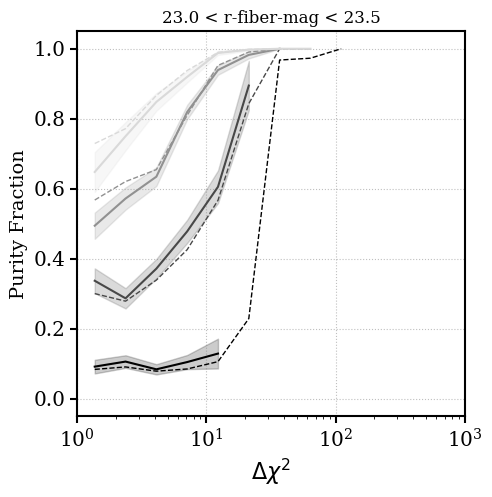

In [162]:
rfib_min=23
rfib_max=23.5

mask = (sum_emi_tot_v2["MAG_R"] > rfib_min)& (sum_emi_tot_v2["MAG_R"] < rfib_max)

ax = plot_1d_purity_fracs(sum_emi_tot_v2,  mask, dchi2_bins = 10**np.arange(0,4.5,np.log10(9)/4), 
                         variable_split = "HALPHA_EW", var_plot_name = "HALPHA_EW", variable_bins = np.array([0,10,20,30,40]),
                         zrr_cut = 0.15,min_bin_count=5,cmap = plt.cm.grey)

ax.set_title(r"%.1f < r-fiber-mag < %.1f"%(rfib_min, rfib_max))

plt.show()
